In [3]:
import zipfile

zip_path = 'crop weed detection dataset.txt.zip'  # Your zip file name

# Extract into a new folder (example: 'dataset')
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')  # This is the folder it will extract to

print("Unzipped successfully!")


Unzipped successfully!


In [4]:
import os

# Check folder structure
print("Extracted folders:", os.listdir('dataset'))


Extracted folders: ['agri_data', 'classes.txt']


In [6]:
import os

# Check what is actually inside the 'dataset' folder
for root, dirs, files in os.walk('dataset'):
    print("📁 Folder:", root)
    for file in files[:5]:  # limit to 5 files per folder
        print("  📄 File:", file)


📁 Folder: dataset
  📄 File: classes.txt
📁 Folder: dataset\agri_data
📁 Folder: dataset\agri_data\data
  📄 File: agri_0_1009.jpeg
  📄 File: agri_0_1009.txt
  📄 File: agri_0_1017.jpeg
  📄 File: agri_0_1017.txt
  📄 File: agri_0_1018.jpeg


In [7]:
import os
import shutil

# Create YOLO folder structure
os.makedirs('dataset/images/train', exist_ok=True)
os.makedirs('dataset/labels/train', exist_ok=True)

# Move images and labels to correct folders
source_dir = 'dataset/agri_data/data'
for filename in os.listdir(source_dir):
    if filename.endswith('.jpeg') or filename.endswith('.jpg') or filename.endswith('.png'):
        shutil.copy(os.path.join(source_dir, filename), 'dataset/images/train')
    elif filename.endswith('.txt'):
        shutil.copy(os.path.join(source_dir, filename), 'dataset/labels/train')

print("Files moved successfully to YOLO folder structure.")


Files moved successfully to YOLO folder structure.


In [8]:
yaml_text = """
train: dataset/images/train
val: dataset/images/train  # you can create val folder later

nc: 2
names: ['crop', 'weed']
"""

with open("dataset/data.yaml", "w") as f:
    f.write(yaml_text)

print("data.yaml created.")


data.yaml created.


In [10]:
!pip install tensorflow opencv-python numpy matplotlib scikit-learn

In [27]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.keras',
 '.matplotlib',
 '.python_history',
 '.virtual_documents',
 '.vscode',
 'age_deploy.prototxt',
 'AI-powered disease.ipynb',
 'anaconda2',
 'anaconda3',
 'app.py',
 'AppData',
 'Application Data',
 'call_logs.csv',
 'cat_dog_classifier.h5',
 'clustered_disease_data.csv',
 'CNNnote.ipynb',
 'Computer_Vision_Classroom Exercise.ipynb',
 'conda',
 'Contacts',
 'Cookies',
 'Covid Data.csv',
 'Covid Data.csv.zip',
 'Covid_Data_2020_to_2025.csv',
 'crop and weed detection.ipynb',
 'crop weed detection',
 'crop_weed_detection',
 'dataset',
 'diabetic.ipynb',
 'disease_outbreak.ipynb',
 'disease_outbreak_system.ipynb',
 'doctor_booking_system',
 'Documents',
 'Downloads',
 'dropout_classification_example.ipynb',
 'Favorites',
 'fraud_model.pkl',
 'fruad call detection.ipynb',
 'fruad detection.py',
 'gender_deploy.prototxt',
 'gukesh.jpg',
 'index.html',
 'Links',
 'Loc

In [29]:
from zipfile import ZipFile

with ZipFile("crop_weed_detection", 'r') as zip_ref:
    zip_ref.extractall("crop_weed_data")

In [30]:
os.listdir("crop_weed_data")

['agri_data', 'classes.txt']

In [34]:
os.listdir("crop_weed_data/agri_data")

['data']

In [35]:
os.listdir("crop_weed_data/agri_data/data")[:10]

['agri_0_1009.jpeg',
 'agri_0_1009.txt',
 'agri_0_1017.jpeg',
 'agri_0_1017.txt',
 'agri_0_1018.jpeg',
 'agri_0_1018.txt',
 'agri_0_1020.jpeg',
 'agri_0_1020.txt',
 'agri_0_1024.jpeg',
 'agri_0_1024.txt']

In [55]:
with open("dataset/agri_data/data/agri_0_1009.txt", "r") as f:
    content = f.read()
print("Contents of agri_0_1009.txt:\n", content)


Contents of agri_0_1009.txt:
 1 0.608398 0.498047 0.541016 0.531250



In [56]:
files = os.listdir("dataset/agri_data/data")
print("Sample files:", files[:10])

Sample files: ['agri_0_1009.jpeg', 'agri_0_1009.txt', 'agri_0_1017.jpeg', 'agri_0_1017.txt', 'agri_0_1018.jpeg', 'agri_0_1018.txt', 'agri_0_1020.jpeg', 'agri_0_1020.txt', 'agri_0_1024.jpeg', 'agri_0_1024.txt']


In [57]:
import os
import shutil

# Paths to folders
base_path = "dataset/agri_data/data"
output_crop = "dataset/crop"
output_weed = "dataset/weed"

# Ensure output folders exist
os.makedirs(output_crop, exist_ok=True)
os.makedirs(output_weed, exist_ok=True)

moved = 0
for filename in os.listdir(base_path):
    if filename.endswith(".txt"):
        txt_path = os.path.join(base_path, filename)
        image_name = filename.replace(".txt", ".jpeg")
        image_path = os.path.join(base_path, image_name)

        if os.path.exists(image_path):
            # Open the .txt file to read the label
            with open(txt_path, "r") as f:
                content = f.read().strip().split(" ")
                label = content[0]  # Get the first value, which is the label

            # Move image based on the label
            if label == "0":  # Crop
                shutil.copy(image_path, os.path.join(output_crop, image_name))
                moved += 1
            elif label == "1":  # Weed
                shutil.copy(image_path, os.path.join(output_weed, image_name))
                moved += 1

print(f"✅ Total images sorted and moved: {moved}")


✅ Total images sorted and moved: 1300


In [58]:
print("Crop images:", len(os.listdir("dataset/crop")))
print("Weed images:", len(os.listdir("dataset/weed")))


Crop images: 634
Weed images: 666


In [59]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers


Total images loaded: 1300


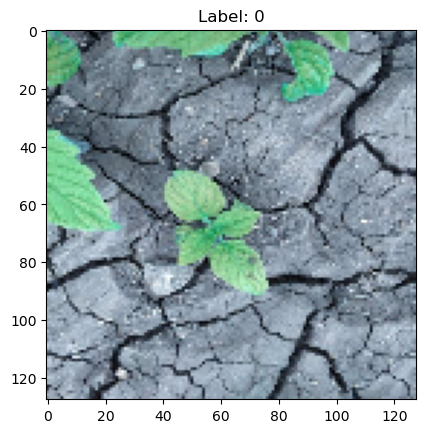

In [60]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Function to load images and labels
def load_images(image_folder, image_size=(128, 128)):
    images = []
    labels = []
    label_map = {'crop': 0, 'weed': 1}  # Crop = 0, Weed = 1

    # Load images and corresponding labels
    for label in ['crop', 'weed']:
        folder_path = os.path.join(image_folder, label)
        for image_name in os.listdir(folder_path):
            if image_name.endswith('.jpeg'):
                img_path = os.path.join(folder_path, image_name)
                img = cv2.imread(img_path)
                img = cv2.resize(img, image_size)  # Resize image
                images.append(img)
                labels.append(label_map[label])

    return np.array(images), np.array(labels)

# Load images and labels
images, labels = load_images("dataset")  # Change to your dataset folder
print(f"Total images loaded: {len(images)}")

# Normalize pixel values to be between 0 and 1
images = images / 255.0

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# Show an example image
plt.imshow(X_train[0])
plt.title(f"Label: {y_train[0]}")
plt.show()


In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build a CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (crop vs. weed)
])

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")


C:\Users\MEGHANA\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.6212 - loss: 0.6519 - val_accuracy: 0.8731 - val_loss: 0.3610
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.8547 - loss: 0.4040 - val_accuracy: 0.9115 - val_loss: 0.3084
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.8852 - loss: 0.3385 - val_accuracy: 0.8846 - val_loss: 0.2954
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.9132 - loss: 0.2847 - val_accuracy: 0.9000 - val_loss: 0.3077
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.8823 - loss: 0.3150 - val_accuracy: 0.8808 - val_loss: 0.2948
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.9091 - loss: 0.2886 - val_accuracy: 0.9269 - val_loss: 0.2132
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 167ms/step - accuracy: 0.9108 - loss: 0.2567 - val_accuracy: 0.9269 - val_loss: 0.2090
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - accuracy: 0.9262 - loss: 0.2246 - val_accuracy: 0.

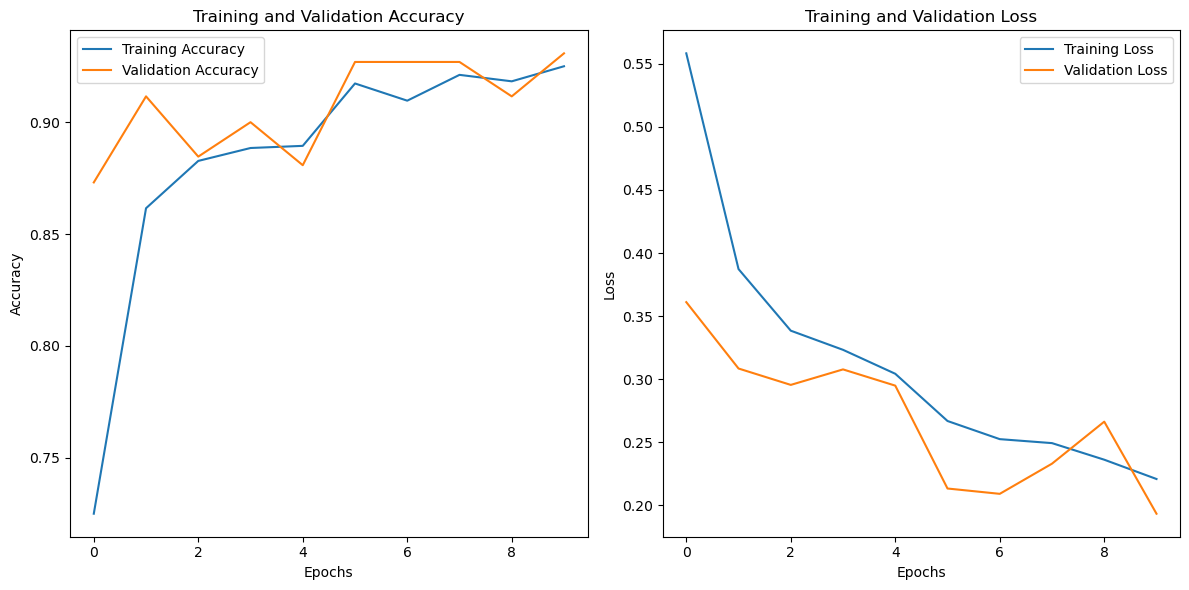

In [62]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [63]:
# Save the trained model
model.save('crop_weed_model.h5')
print("Model saved as 'crop_weed_model.h5'")


Model saved as 'crop_weed_model.h5'


In [64]:
# Load the saved model
from tensorflow.keras.models import load_model

model = load_model('crop_weed_model.h5')

# Example: Predict the class for the first test image
import numpy as np
img = np.expand_dims(X_test[0], axis=0)  # Reshape image to (1, 128, 128, 3)
prediction = model.predict(img)

# Print the predicted label
predicted_label = "weed" if prediction[0] > 0.5 else "crop"
print(f"Predicted label: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted label: crop


In [65]:
pip install flask


Note: you may need to restart the kernel to use updated packages.


In [66]:
from flask import Flask, render_template, request, jsonify
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import cv2

# Initialize the Flask application
app = Flask(__name__)

# Load the pre-trained model
model = load_model('crop_weed_model.h5')

# Define the image upload folder
UPLOAD_FOLDER = 'uploads/'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

# Prediction function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Expand dims to match the batch size
    prediction = model.predict(img_array)
    return "weed" if prediction[0] > 0.5 else "crop"

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file part'})
    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'No selected file'})
    
    # Save the uploaded file
    file_path = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
    file.save(file_path)

    # Predict the class
    result = predict_image(file_path)

    return jsonify({'prediction': result})

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (windowsapi)


SystemExit: 1

C:\Users\MEGHANA\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3554: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [67]:
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Crop vs Weed Detection</title>
</head>
<body>
    <h1>Upload an Image to Detect Crop or Weed</h1>
    <form action="/predict" method="POST" enctype="multipart/form-data">
        <input type="file" name="file" accept="image/*" required>
        <button type="submit">Upload</button>
    </form>

    <div id="prediction_result">
        <!-- Prediction will be displayed here -->
    </div>

    <script>
        // Optional: Handle the file upload with AJAX to avoid page reload
        const form = document.querySelector('form');
        form.onsubmit = async (e) => {
            e.preventDefault();
            const formData = new FormData(form);
            const response = await fetch('/predict', {
                method: 'POST',
                body: formData
            });
            const data = await response.json();
            const prediction = data.prediction;

            document.getElementById('prediction_result').innerHTML = `<h3>Prediction: ${prediction}</h3>`;
        };
    </script>
</body>
</html>


SyntaxError: invalid syntax (3513713158.py, line 1)

In [68]:
python app.py


SyntaxError: invalid syntax (2255720966.py, line 1)